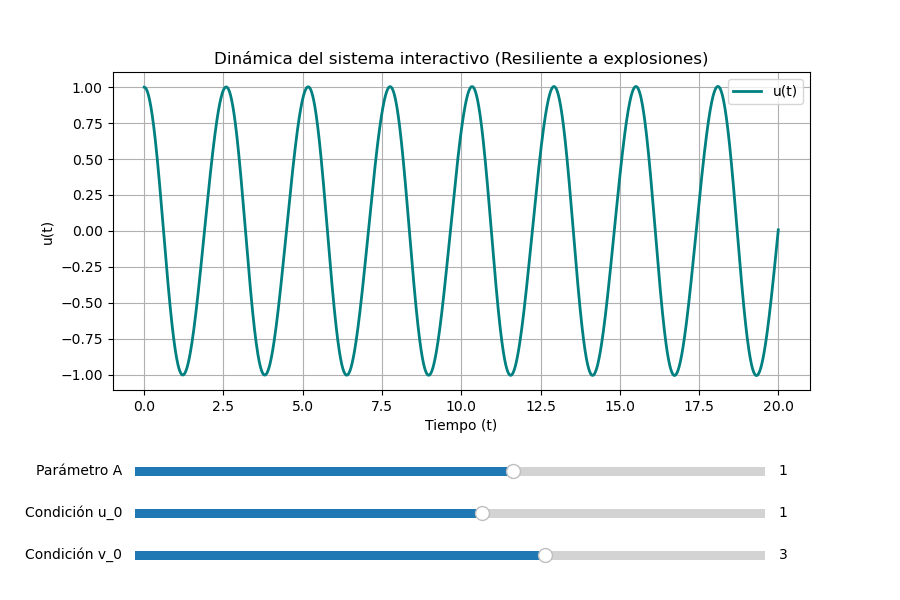

In [ ]:
%matplotlib widget

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# 1. Configuración de tiempo
time_end = 20
t_eval = np.linspace(0, time_end, 2000) 

# 2. Definimos el sistema
def ODE_system(t, y, A):
    u, v = y
    du_dt = (4 * A + 2) * v - 2 * v**2
    dv_dt = u
    return [du_dt, dv_dt]

# 3. Condiciones iniciales por defecto
A_init = 1.0
u0_init = 1.0
v0_init = 2 * A_init + 1

sol = solve_ivp(
    fun=lambda t, y: ODE_system(t, y, A_init),
    t_span=[0, time_end],
    y0=[u0_init, v0_init],
    t_eval=t_eval
)

# 4. Preparamos la figura
fig, ax = plt.subplots(figsize=(9, 6))
plt.subplots_adjust(bottom=0.35) 

# Guardamos la línea de la gráfica
line, = ax.plot(sol.t, sol.y[1], lw=2, color='teal', label='v(t)')
ax.set_xlabel('Tiempo (t)')
ax.set_ylabel('u(t)')
ax.set_title('Dinámica del sistema interactivo (Resiliente a explosiones)')
ax.grid(True)
ax.legend()

# 5. Creación de los Sliders
ax_A = plt.axes([0.15, 0.20, 0.70, 0.03])
ax_u0 = plt.axes([0.15, 0.13, 0.70, 0.03])
ax_v0 = plt.axes([0.15, 0.06, 0.70, 0.03])

slider_A = Slider(ax=ax_A, label='Parámetro A', valmin=-5.0, valmax=5.0, valinit=A_init)
slider_u0 = Slider(ax=ax_u0, label='Condición u_0', valmin=-10.0, valmax=10.0, valinit=u0_init)
slider_v0 = Slider(ax=ax_v0, label='Condición v_0', valmin=-10.0, valmax=10.0, valinit=v0_init)

# 6. Función de actualización corregida
def update(val):
    A_val = slider_A.val
    u0_val = slider_u0.val
    v0_val = slider_v0.val
    
    new_sol = solve_ivp(
        fun=lambda t, y: ODE_system(t, y, A_val),
        t_span=[0, time_end],
        y0=[u0_val, v0_val],
        t_eval=t_eval
    )
    
    # ¡EL CAMBIO CLAVE! 
    # set_data actualiza X e Y al mismo tiempo, adaptándose si SciPy frena antes
    line.set_data(new_sol.t, new_sol.y[1])
    
    # Reajustamos los límites de X (por si el tiempo se acortó debido a la explosión)
    ax.set_xlim(new_sol.t[0], new_sol.t[-1])
    
    # Reajustamos los límites de Y
    ax.relim()
    ax.autoscale_view()
    
    fig.canvas.draw_idle()

slider_A.on_changed(update)
slider_u0.on_changed(update)
slider_v0.on_changed(update)

plt.show()

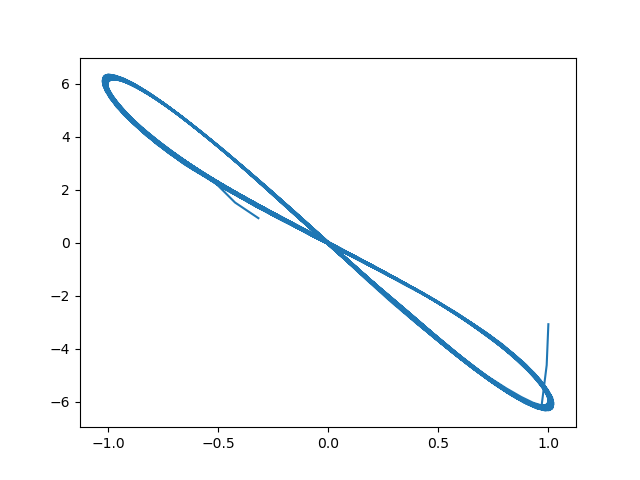

In [ ]:
%matplotlib widget

plt.figure()
def ODE_system(t, y, A):
    u, v = y
    du_dt = (4 * A + 2) * v - 2 * v**2
    dv_dt = u
    return [du_dt, dv_dt]

A = 1
u0 = 1
v0 = 2 * A + 1  
time_end = 100
t_eval = np.linspace(0, time_end, 2000) 

sol = solve_ivp(
        fun=lambda t, y: ODE_system(t, y, A),
        t_span=[0, time_end],
        y0=[u0, v0],
        t_eval=t_eval
    )

y = sol.y[0]
t = sol.t
V = (4 * A + 2) * y - 2 * y**2

y_dotdot = np.gradient(np.gradient(y, t), t)
plt.plot(y, y_dotdot)
plt.show()